# Архитектура сквозной системы машинного обучения: объединение ансамбля блендинга ( TimeSeries, классический ML).

```text
[Данные] ──► [ Модули Блендинга: + SARIMA + Prophet + CatBoostRegressor]
                                 │
                                 ▼
                     [ Мета-модель (БлендCatBoostClassifier) ]
                                 │ (Вектор признаков / Сигнал)
                                 ▼
```

1 TimeSeries-модели
model_ts_1: SARIMA

model_ts_2: Prophet

Каждая выдает:

прогноз на horizon 5, 10, 15 мин

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

import os
import requests
from dotenv import load_dotenv
load_dotenv() 
Authorization = os.getenv("Authorization")
headers = {
  'Accept': 'application/json',
  'Authorization': Authorization,
}
payload = {}
from clickhouse_driver import Client
import datetime

In [2]:
from catboost import CatBoostRegressor, Pool

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller

# data

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
class ClickHouseProcessor(Client):
    def __init__(self, host='localhost', port=9000):
       super().__init__(
            host=host, 
            port=port,
            user='default',
            password='default'
        )

    def drop(self, table_name):
        """db.table"""
        query = f"""
        DROP TABLE IF EXISTS {table_name}
        """
        try:
            self.execute(query)
            logging.error(e)(f"удаление таблицы {table_name}")
        except Exception as e:
            logging.error(e)(f"error: {e}, при удаление таблицы {table_name}")

    def truncate_table(self, db, table_name):

        query = f"""
        TRUNCATE TABLE IF EXISTS {db}.{table_name}
        """
        try:
            self.execute(query)
            logging.error(e)(f"выполнена очистка данных таблицы {db}.{table_name}")
        except Exception as e:
            logging.error(e)(f"error: {e}, при очистки таблицы {db}.{table_name}")

    def get_report(self, limit=100, table='test_tradestats'):
        """
        Возвращает отчет о последних выполненных запросах из системного лога.
        Требует прав доступа к таблице system.query_log.
        """
        report_sql = f"""
        SELECT 
            event_time,
            query, 
            query_duration_ms / 1000 AS seconds, 
            read_rows, 
            formatReadableSize(read_bytes) AS memory
        FROM system.query_log
        WHERE query LIKE '%{table}%' AND type = 'QueryFinish' AND query NOT LIKE '%system.query_log%' 
        ORDER BY event_time DESC
        LIMIT {limit}
        """
        return self.query_dataframe(report_sql)

    def drop_duplicated(self, db, table='test_tradestats'):
        """
        Удаление дубликатов в таблице
        """

        return client.execute(f'OPTIMIZE TABLE {db}.{table} FINAL')


#=============================================================================================
    def sql_limit_select_all_secid(self, db, table_name, limit:int, interval):
        """
        Берем только последние limit строк каждого поледнего secid
        во временном интервале от текушей даты (день)
        """


        query = f"""
                SELECT *
                FROM 
                (SELECT secid, tradetime, pr_close
                FROM {db}.{table_name}
                WHERE tradetime >= today() - INTERVAL {interval} DAY
                ORDER BY secid, tradetime DESC
                LIMIT {limit} by secid
                )
                ORDER BY secid, tradetime
                """
        return slf.query

    def sql_limit_secid(self,secid:str , db:str, table_name:str, limit:int, interval:int):
        """
        Берем только последние limit строк выбранного secid
        во временном интервале (день - int) от текушей даты (день)

        """


        query = f"""
                    SELECT *
                    FROM 
                    (SELECT secid, tradetime, pr_close
                    FROM {db}.{table_name}
                    PREWHERE secid = '{secid}' AND tradetime >= today() - INTERVAL {interval} DAY
                    ORDER BY tradetime DESC
                    LIMIT {limit} 
                    )
                    ORDER BY  tradetime
                    """
        return self.query_dataframe(query)

    def get_latest_window(self, secid='GAZP', window_size=200):
        sql =f"""
        SELECT *
        FROM (
            SELECT tradetime,
                    pr_open,
                    pr_high,
                    pr_low,
                    pr_close,
                    pr_std,
                    vol,
                    val,
                    trades,
                    pr_vwap,
                    pr_change,
                    trades_b,
                    trades_s, 
                    val_b,
                    val_s,
                    vol_b, 
                    vol_s, disb,
                    pr_vwap_b,
                    pr_vwap_s
            FROM test_trade.test_tradestats
            WHERE secid = '{secid}' AND tradetime >= today() - INTERVAL 3 DAY
            ORDER BY tradetime DESC
            LIMIT {window_size}
        )
        ORDER BY tradetime ASC
        """
        return client.query_dataframe(sql, settings={'optimize_read_in_order': 1, 'max_block_size': window_size})




In [6]:
client = ClickHouseProcessor()
client.execute('SELECT version();')

[('25.1.2.3',)]

In [7]:
sql = """
SELECT tradetime,
        pr_open,
        pr_high,
        pr_low,
        pr_close,
        pr_std,
        vol,
        val,
        trades,
        pr_vwap,
        pr_change,
        trades_b,
        trades_s, 
        val_b,
        val_s,
        vol_b, 
        vol_s, disb,
        pr_vwap_b,
        pr_vwap_s
FROM test_trade.test_tradestats
WHERE secid = 'GAZP'
ORDER BY tradetime ASC
"""
data = client.query_dataframe(sql)
data = data.fillna(0)
data.head()

,tradetime,pr_open,pr_high,pr_low,pr_close,pr_std,vol,val,trades,pr_vwap,pr_change,trades_b,trades_s,val_b,val_s,vol_b,vol_s,disb,pr_vwap_b,pr_vwap_s
0,2020-01-03 10:05:00+03:00,259.10,259.70,258.52,259.51,0.0002,131731,341224784.0,1879,259.03,0.1582,1016,863,164398001.0,176826782.0,63452,68279,-0.04,259.09,258.98
1,2020-01-03 10:10:00+03:00,259.51,259.96,259.08,259.95,0.0001,61344,159193591.0,922,259.51,0.1696,510,412,105735775.0,53457815.0,40736,20608,0.33,259.56,259.40
2,2020-01-03 10:15:00+03:00,259.90,260.27,259.21,259.50,0.0001,75968,197407691.0,1115,259.86,-0.1539,567,548,143624900.0,53782790.0,55261,20707,0.45,259.90,259.73
3,2020-01-03 10:20:00+03:00,259.52,259.77,259.33,259.43,0.0001,24204,62821478.0,479,259.55,-0.0347,253,226,30247547.0,32573931.0,11653,12551,-0.04,259.57,259.53
4,2020-01-03 10:25:00+03:00,259.47,259.70,259.32,259.62,0.0001,17593,45662609.0,427,259.55,0.0578,301,126,31943442.0,13719167.0,12306,5287,0.40,259.58,259.49


In [8]:
data

,tradetime,pr_open,pr_high,pr_low,pr_close,pr_std,vol,val,trades,pr_vwap,pr_change,trades_b,trades_s,val_b,val_s,vol_b,vol_s,disb,pr_vwap_b,pr_vwap_s
0,2020-01-03 10:05:00+03:00,259.10,259.70,258.52,259.51,0.0002,131731,341224784.0,1879,259.03,0.1582,1016,863,164398001.0,176826782.0,63452,68279,-0.04,259.09,258.98
1,2020-01-03 10:10:00+03:00,259.51,259.96,259.08,259.95,0.0001,61344,159193591.0,922,259.51,0.1696,510,412,105735775.0,53457815.0,40736,20608,0.33,259.56,259.40
2,2020-01-03 10:15:00+03:00,259.90,260.27,259.21,259.50,0.0001,75968,197407691.0,1115,259.86,-0.1539,567,548,143624900.0,53782790.0,55261,20707,0.45,259.90,259.73
3,2020-01-03 10:20:00+03:00,259.52,259.77,259.33,259.43,0.0001,24204,62821478.0,479,259.55,-0.0347,253,226,30247547.0,32573931.0,11653,12551,-0.04,259.57,259.53
4,2020-01-03 10:25:00+03:00,259.47,259.70,259.32,259.62,0.0001,17593,45662609.0,427,259.55,0.0578,301,126,31943442.0,13719167.0,12306,5287,0.40,259.58,259.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274956,2026-07-06 17:15:00+03:00,96.15,96.15,95.80,95.83,0.0001,98729,94734720.0,1223,95.95,-0.3328,570,653,42844869.0,51889851.0,44652,54077,-0.10,95.95,95.96
274957,2026-07-06 17:20:00+03:00,95.83,96.04,95.57,95.72,0.0001,97743,93685908.0,1262,95.85,-0.1148,498,764,19286583.0,74399325.0,20129,77614,-0.59,95.81,95.86
274958,2026-07-06 17:25:00+03:00,95.70,95.80,95.63,95.67,0.0001,26744,25599641.0,604,95.72,-0.0313,314,290,12301743.0,13297898.0,12851,13893,-0.04,95.73,95.72
274959,2026-07-06 17:30:00+03:00,95.67,96.40,95.60,96.15,0.0001,128848,123831985.0,1428,96.11,0.5017,949,479,72340484.0,51491500.0,75293,53555,0.17,96.08,96.15


In [11]:
def preprocessing_ts(data):
    df_ticker = data[['tradetime', 'pr_close']].rename(columns={'tradetime': 'ds', 'pr_close': 'y'})
    df_ticker['ds'] = pd.to_datetime(df_ticker['ds']).dt.tz_localize(None)
    df_ticker = df_ticker.sort_values('ds').reset_index(drop=True)
    return df_ticker

In [13]:
df_ticker = preprocessing_ts(data)

In [14]:
df_ticker

,ds,y
0,2020-01-03 10:05:00,259.51
1,2020-01-03 10:10:00,259.95
2,2020-01-03 10:15:00,259.50
3,2020-01-03 10:20:00,259.43
4,2020-01-03 10:25:00,259.62
...,...,...
271445,2026-06-11 12:10:00,113.14
271446,2026-06-11 12:15:00,113.12
271447,2026-06-11 12:20:00,113.14
271448,2026-06-11 12:25:00,113.13


In [15]:
result = adfuller(df_ticker['y'])

In [16]:
def return_result_adfuller(result, alpha=0.05):
    """
    Нулевая гипотеза (H0): Ряд имеет единичный корень (нестационарный).
    Альтернативная гипотеза (H1): Ряд стационарный.

    Смотрим на ADF Statistic (первое значение).

    Смотрим на Critical Values (пятое значение — это словарь {'1%': ..., '5%': ..., '10%': ...}).

    Правило: Чем более отрицательная статистика, тем увереннее мы можем отвергнуть нестационарность.

    Если ADF Statistic < Critical Value (1%): Ряд стационарен с уверенностью 99%.

    Если ADF Statistic < Critical Value (5%): Ряд стационарен с уверенностью 95%.

    Если ADF Statistic > Critical Value (10%): Ряд нестационарен.
    """

    p_value = result[1]
    adf_stat = result[0]
    print(f'alpha: {alpha}')
    print('ADF статистика:', adf_stat)
    print('p-значение:', p_value)
    if p_value <= alpha:
        print("Отвергаем нулевую гипотезу. Вывод: Ряд стационарный. p_value <= alpha")
    elif p_value > alpha:
        print("Вывод: Ряд нестационарный (содержит единичный корень, тренд или сезонность). p_value > alpha")

    for key, value in result[4].items():

        if adf_stat < value:
            print(f"Ряд стационарен с уверенностью {key}. {value}. Критическое значение: {key}: {value}. ADF статистика:{adf_stat}")
        else:
            print(f"Ряд не стационарен. Критическое значение: {key}: {value}. ADF статистика:{adf_stat}")

In [17]:
return_result_adfuller(result, alpha=0.05)

alpha: 0.05
ADF статистика: -1.7223287034979964
p-значение: 0.4196463248631107
Вывод: Ряд нестационарный (содержит единичный корень, тренд или сезонность). p_value > alpha
Ряд не стационарен. Критическое значение: 1%: -3.430374357798516. ADF статистика:-1.7223287034979964
Ряд не стационарен. Критическое значение: 5%: -2.8615507658397794. ADF статистика:-1.7223287034979964
Ряд не стационарен. Критическое значение: 10%: -2.5667757302668184. ADF статистика:-1.7223287034979964


In [22]:
result = adfuller(df_ticker['y'].diff().dropna()) # .diff()
return_result_adfuller(result, alpha=0.05)

alpha: 0.05
ADF статистика: -54.86347883654887
p-значение: 0.0
Отвергаем нулевую гипотезу. Вывод: Ряд стационарный. p_value <= alpha
Ряд стационарен с уверенностью 1%. -3.4303743578892454. Критическое значение: 1%: -3.4303743578892454. ADF статистика:-54.86347883654887
Ряд стационарен с уверенностью 5%. -2.86155076587988. Критическое значение: 5%: -2.86155076587988. ADF статистика:-54.86347883654887
Ряд стационарен с уверенностью 10%. -2.5667757302881626. Критическое значение: 10%: -2.5667757302881626. ADF статистика:-54.86347883654887


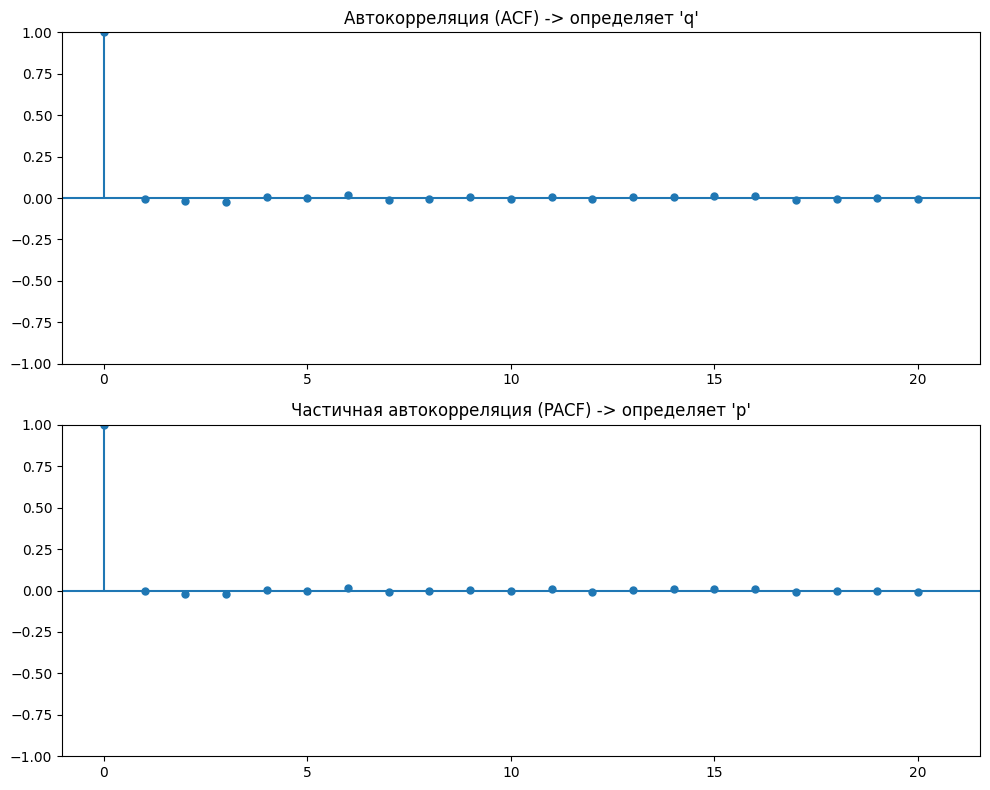

In [97]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Берем первую разность цены (приросты), очищаем от первого NaN
# Это переводит абсолютную цену GAZP в формат "изменение цены за 5 минут"
price_diff = df_ticker['y'].diff().dropna()

# 2. Настройка графического окна
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 3. Строим график ACF (определяет параметр q — Скользящее среднее)
# lags=20 означает, что мы смотрим связь на 20 бар назад (100 минут торгов)
plot_acf(price_diff, lags=20, ax=ax1, title="Автокорреляция (ACF) -> определяет 'q'")

# 4. Строим график PACF (определяет параметр p — Авторегрессия)
plot_pacf(price_diff, lags=20, ax=ax2, title="Частичная автокорреляция (PACF) -> определяет 'p'")

plt.tight_layout()
plt.show()

In [ ]:
import pmdarima as pm
#df_ticker['log_return'] = np.log(df_ticker['y'] / df_ticker['y'].shift(1))

# 2. Обучаем модель (удаляем первую строку NaN)
auto_model = pm.auto_arima(
    df_ticker['y'], 
    d=1,             
    start_p=0, max_p=4, 
    start_q=0, max_q=4, 
    seasonal=True,     
    stepwise=True,      
    trace=True          
)
print("\n--- ЛУЧШИЕ ПАРАМЕТРЫ ДЛЯ РОБОТА ---")
print(auto_model.summary())

# Извлекаем лучшие параметры
best_p, best_d, best_q = auto_model.order
print(f"\nРекомендуемая конфигурация: order=({best_p}, {best_d}, {best_q})")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=290294.019, Time=14.60 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=290290.717, Time=17.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=290290.501, Time=7.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=290292.459, Time=3.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=290292.611, Time=8.62 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=290189.265, Time=22.96 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=290133.768, Time=16.27 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=290071.641, Time=41.96 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=290129.181, Time=42.25 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=290054.339, Time=51.98 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=290072.112, Time=7.61 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=290070.553, Time=28.63 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=290080.323, Time=35.70 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=290055.156, Time=52.05

In [99]:
auto_model.order

(3, 1, 2)

In [15]:
data_200 = client.get_latest_window(secid='GAZP', window_size=200)
data_200

,tradetime,pr_open,pr_high,pr_low,pr_close,pr_std,vol,val,trades,pr_vwap,pr_change,trades_b,trades_s,val_b,val_s,vol_b,vol_s,disb,pr_vwap_b,pr_vwap_s
0,2026-06-10 12:45:00+03:00,112.41,112.44,112.34,112.41,0.0001,3268,3673064.0,183,112.39,0.0000,83,100,816050.0,2857014.0,726,2542,-0.56,112.40,112.39
1,2026-06-10 12:50:00+03:00,112.40,112.71,112.40,112.62,0.0001,16404,18472209.0,425,112.61,0.1957,309,116,13984151.0,4488058.0,12419,3985,0.51,112.60,112.62
2,2026-06-10 12:55:00+03:00,112.63,112.68,112.60,112.63,0.0001,3606,4061662.0,238,112.64,0.0000,173,65,3092973.0,968688.0,2746,860,0.52,112.64,112.64
3,2026-06-10 13:00:00+03:00,112.63,112.64,112.52,112.53,0.0001,6001,6756241.0,250,112.59,-0.0888,126,124,1673908.0,5082333.0,1487,4514,-0.50,112.57,112.59
4,2026-06-10 13:05:00+03:00,112.53,112.65,112.45,112.63,0.0001,6928,7798797.0,241,112.57,0.0889,126,115,6040253.0,1758544.0,5365,1563,0.55,112.59,112.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2026-06-11 12:10:00+03:00,113.14,113.28,113.09,113.14,0.0001,25565,28929551.0,318,113.16,0.0000,199,119,20483379.0,8446172.0,18101,7464,0.42,113.16,113.16
196,2026-06-11 12:15:00+03:00,113.15,113.17,113.06,113.12,0.0001,7320,8279886.0,199,113.11,-0.0265,98,101,3803433.0,4476453.0,3362,3958,-0.08,113.13,113.10
197,2026-06-11 12:20:00+03:00,113.13,113.21,113.12,113.14,0.0001,3412,3860705.0,166,113.15,0.0088,94,72,1991730.0,1868975.0,1760,1652,0.03,113.17,113.13
198,2026-06-11 12:25:00+03:00,113.15,113.19,113.12,113.13,0.0001,6572,7436113.0,155,113.15,-0.0177,91,64,5015215.0,2420898.0,4432,2140,0.35,113.16,113.13


# model_ts_1: SARIMAX

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

class RealTimeForecaster:
    def __init__(self, p=3, q=2):
        self.p = p
        self.q = q
        
    def predict_on_dataframe(self, df_window):
        """
        Принимает готовый DataFrame из ClickHouse (колонки 'tradetime' и 'pr_close')
        """
        df_ticker = df_window[['tradetime', 'pr_close']].rename(columns={'tradetime': 'ds', 'pr_close': 'y'})
        df_ticker['ds'] = pd.to_datetime(df_ticker['ds']).dt.tz_localize(None)
        
        if len(df_ticker) < max(self.p, self.q) + 10:
            return None
            
        
        try:
            # Обучаем на данных (d=1)
            model = SARIMAX(
                df_ticker['y'], 
                order=(self.p, 1, self.q), 
                enforce_stationarity=False, 
                enforce_invertibility=False
            )
            model_fitted = model.fit(disp=False)
            
            # Быстрый точечный прогноз на 3 шага вперед
            return_pred = model_fitted.forecast(steps=3)
            
            # Генерация временной сетки MoEX
            predictions = self._generate_future_timestamps(
                last_time=df_ticker['ds'].iloc[-1], 
                values=return_pred
            )
            return predictions
            
        except Exception as e:
            print(f"Ошибка в расчете ARIMA: {e}")
            return None

    def _generate_future_timestamps(self, last_time, values):
        """
        Генерирует сетку времени MoEX без ночи и выходных
        """
        future_times = pd.date_range(start=last_time + pd.Timedelta(minutes=5), periods=50, freq='5min')
        
        start_session = pd.to_datetime('06:50:00').time()
        end_session = pd.to_datetime('23:50:00').time()
        valid_times = future_times[(future_times.time >= start_session) & (future_times.time <= end_session)]
        
        valid_times = valid_times[~((valid_times.time > pd.to_datetime('18:50:00').time()) & 
                                    (valid_times.time < pd.to_datetime('19:00:00').time()))]
        
        return pd.DataFrame({
            'tradetime': valid_times[:3],
            'horizon': ['5', '10', '15'],
            'return_pred': np.round(values, 6)
        })


In [17]:
forecaster = RealTimeForecaster(p=3, q=2)
forecaster.predict_on_dataframe(data_200)

,tradetime,horizon,return_pred
200,2026-06-11 12:35:00,5,113.374535
201,2026-06-11 12:40:00,10,113.392869
202,2026-06-11 12:45:00,15,113.397747


# model_ts_2: Prophet

In [18]:
from prophet import Prophet

In [19]:
idx_split = int(len(data) * 0.7)

In [167]:
df_ticker_train = df_ticker.iloc[:idx_split].copy()
df_ticker_test = df_ticker.iloc[idx_split:].copy()

21:53:18 - cmdstanpy - INFO - Chain [1] start processing
21:55:46 - cmdstanpy - INFO - Chain [1] done processing


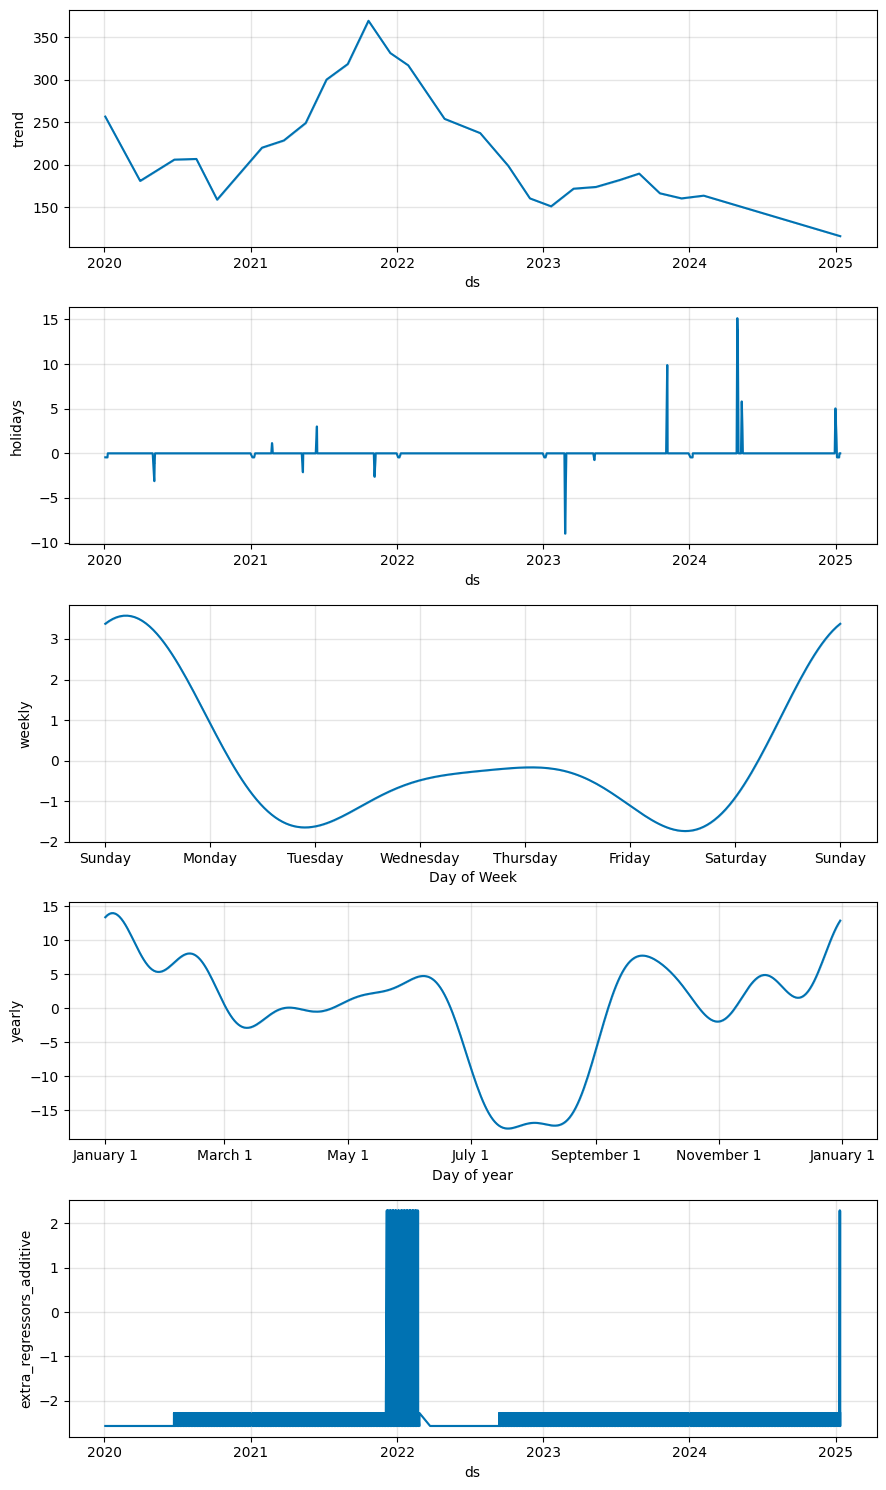

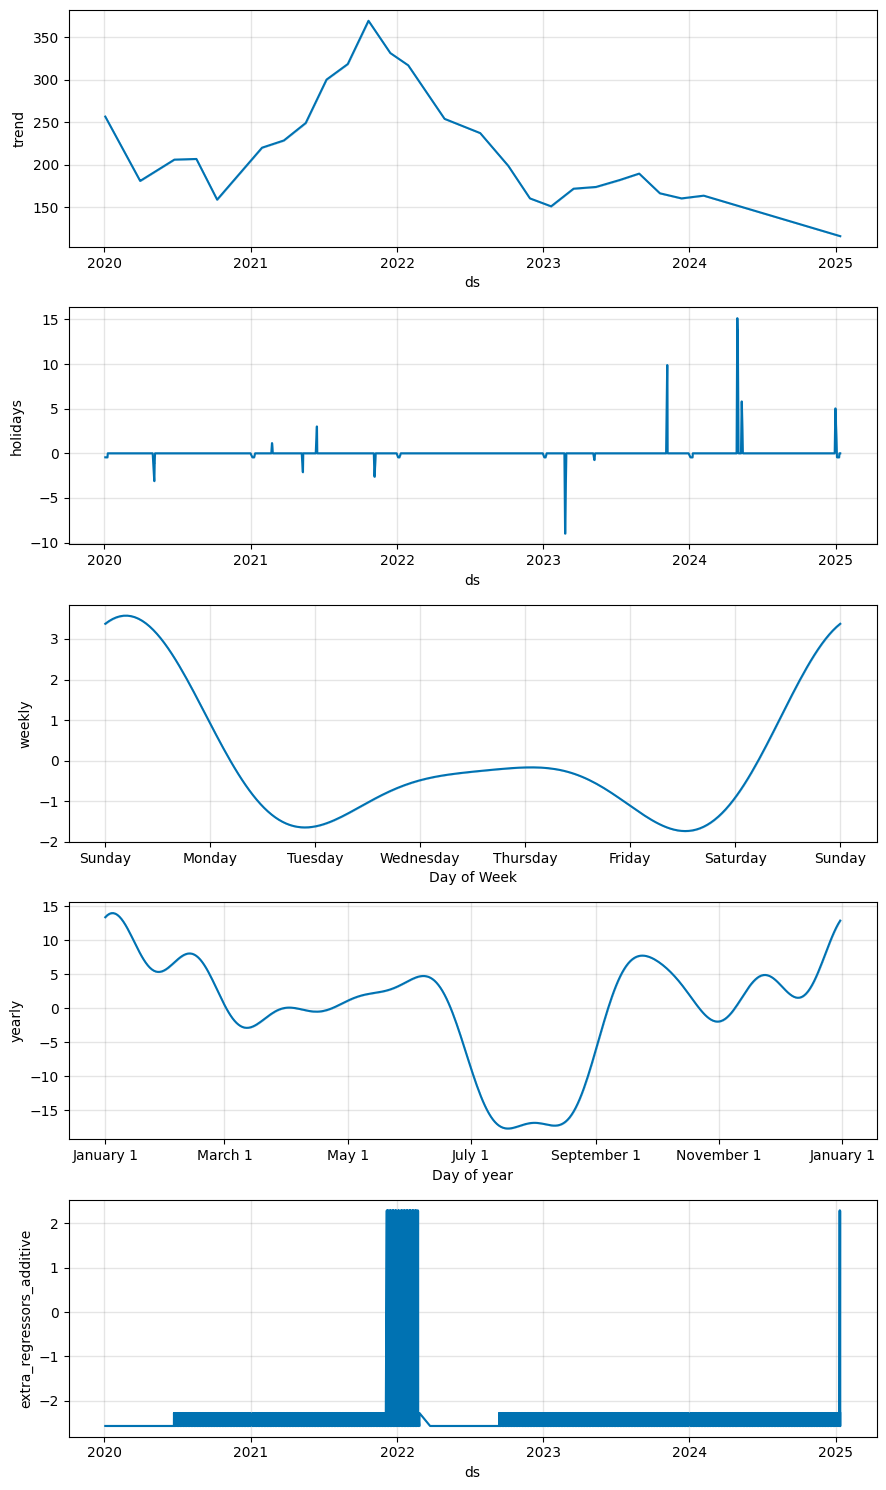

In [168]:
import numpy as np
import pandas as pd
from prophet import Prophet

# ==========================================
# 1. ФУНКЦИИ РАЗМЕТКИ СЕССИЙ И ТОРГОВОГО КАЛЕНДАРЯ
# ==========================================

def add_session_features(df):
    """Размечает 5-минутные бары по трем сессиям Мосбиржи."""
    df = df.copy()
    times = pd.to_datetime(df['ds']).dt.time
    
    # Утренняя сессия (06:50:00 - 09:59:59)
    df['morning_session'] = ((times >= pd.to_datetime('06:50:00').time()) & 
                             (times < pd.to_datetime('10:00:00').time())).astype(int)
    
    # Основная сессия (10:00:00 - 18:59:59)
    df['main_session'] = ((times >= pd.to_datetime('10:00:00').time()) & 
                           (times < pd.to_datetime('19:00:00').time())).astype(int)
    
    # Вечерняя сессия (19:00:00 - 23:50:00)
    df['evening_session'] = ((times >= pd.to_datetime('19:00:00').time()) & 
                             (times <= pd.to_datetime('23:50:00').time())).astype(int)
    return df

def filter_market_hours(df):
    """Оставляем строго интервал торгов 06:50 - 23:50"""
    df = df.copy()
    dt_series = pd.to_datetime(df['ds'])
    
    # Оставляем только дни с понедельника по пятницу
    #df = df[dt_series.dt.weekday < 5]
    
    # Оставляем строго интервал торгов 06:50 - 23:50
    times = pd.to_datetime(df['ds']).dt.time
    start = pd.to_datetime('06:50:00').time()
    end = pd.to_datetime('23:50:00').time()
    df = df[(times >= start) & (times <= end)]
    
    return df

# ==========================================
# 2. ИНИЦИАЛИЗАЦИЯ И ОБУЧЕНИЕ МОДЕЛИ
# ==========================================

# Готовим обучающий датасет ( df_ticker должен содержать 'ds' и 'y' )


# 3. Размечаем сессии на очищенных данных
prophet_data = add_session_features(df_ticker_train)
model = Prophet(
    changepoint_prior_scale=0.05,
    yearly_seasonality=True,
    weekly_seasonality=True,   # Отлично уловит динамику дней недели при 5-минутках
    daily_seasonality=False,# Отключаем стандартную суточную 24h сезонность
    interval_width=0.80,
)
model.add_country_holidays(country_name='RU')

# Добавляем кастомные регрессоры сессий
model.add_regressor('morning_session')
model.add_regressor('main_session')
model.add_regressor('evening_session')

# Обучаем модель
model.fit(prophet_data)

# ==========================================
# 3. ГЕНЕРАЦИЯ ПРАВИЛЬНОГО БУДУЩЕГО ДЛЯ 5-МИНУТОК
# ==========================================

# Пример: Хотим построить прогноз на 2 торговых дня вперед.
# В одном торговом дне (с 06:50 до 23:50) содержится ровно 205 пятиминутных баров.
# 2 дня * 205 баров = 410 баров (ставим с запасом 600, так как лишние выходные отфильтруются)
future_raw = model.make_future_dataframe(periods=600, freq='5min', include_history=True)

# Очищаем будущую сетку от ночи и выходных
future_filtered = filter_market_hours(future_raw)

# Добавляем признаки сессий для будущего периода (обязательно для add_regressor)
future_ready = add_session_features(future_filtered)

# ==========================================
# 4. СТРОИМ ПРОГНОЗ
# ==========================================
forecast = model.predict(future_ready)

# Смотрим результат (тренды, недельная сезонность и эффекты сессий)
model.plot_components(forecast)

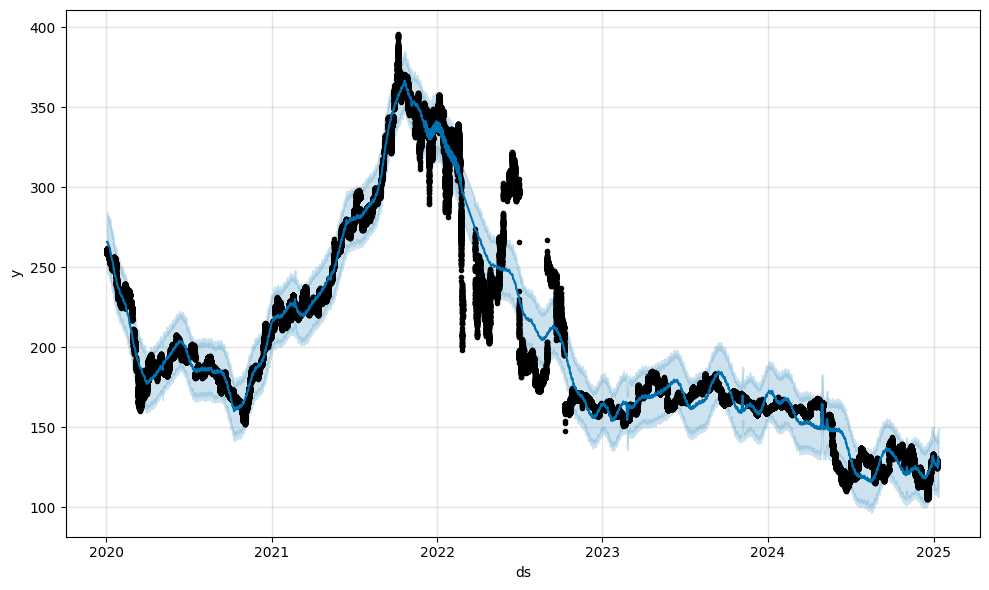

In [169]:
fig1 = model.plot(forecast)

In [170]:
import json
from prophet import Prophet
from prophet.serialize import model_to_json, model_from_json

# ==========================================
# 1. НА СЕРВЕРЕ ОБУЧЕНИЯ (Запускается, например, раз в неделю)
# ==========================================
def save_trained_model(model, filepath="prophet_model.json"):
    """Конвертирует модель Prophet в формат JSON и сохраняет на диск."""
    with open(filepath, 'w') as f:
        # model_to_json превращает веса и параметры модели в строку
        json.dump(model_to_json(model), f)
    print(f"Успешно! Модель сохранена в файл: {filepath}")


# ==========================================
# 2. В ТОРГОВОМ РОБОТЕ (Запускается утром перед открытием биржи)
# ==========================================
def load_trained_model(filepath="prophet_model.json"):
    """Загружает модель из файла JSON без необходимости доступа к истории."""
    with open(filepath, 'r') as f:
        model_str = json.load(f)
        # Восстанавливаем полноценный объект Prophet из строки
        model = model_from_json(model_str)
    print("Успешно! Модель загружена и готова к прогнозированию.")
    return model

In [171]:
save_trained_model(model, filepath="prophet_model.json")

Успешно! Модель сохранена в файл: prophet_model.json


In [20]:
import warnings
import json
import numpy as np
import pandas as pd
from prophet.serialize import model_from_json

warnings.filterwarnings('ignore')

class RealTimeProphetForecaster:
    def __init__(self, model_json_path):
        """Принимает путь к сохраненной модели JSON"""
        with open(model_json_path, "r", encoding='utf-8') as f:
            self.model = model_from_json(json.load(f))
        
    def _add_session_features(self, df):
        """Внутренний метод разметки сессий MoEX для векторов Prophet"""
        df = df.copy()
        times = pd.to_datetime(df['ds']).dt.time
        
        df['morning_session'] = ((times >= pd.to_datetime('06:50:00').time()) & 
                                 (times < pd.to_datetime('10:00:00').time())).astype(int)
        df['main_session'] = ((times >= pd.to_datetime('10:00:00').time()) & 
                               (times < pd.to_datetime('19:00:00').time())).astype(int)
        df['evening_session'] = ((times >= pd.to_datetime('19:00:00').time()) & 
                                 (times <= pd.to_datetime('23:50:00').time())).astype(int)
        return df

    def predict_on_dataframe(self, df_window):
        """
        Принимает DataFrame из ClickHouse (колонки 'tradetime' и 'pr_close')
        """
        # Преобразование под формат модели и очистка от таймзон
        df_ticker = df_window[['tradetime', 'pr_close']].rename(columns={'tradetime': 'ds', 'pr_close': 'y'})
        df_ticker['ds'] = pd.to_datetime(df_ticker['ds']).dt.tz_localize(None)
        
        if len(df_ticker) < 1:
            return None
            
        last_time = df_ticker['ds'].iloc[-1]
        actual_price = df_ticker['y'].iloc[-1]
        
        try:
            # 1. Генерируем временную сетку MoEX без ночи/выходных/клирингов
            valid_times = self._generate_future_timestamps(last_time)
            
            # Собираем DataFrame: текущая точка (для калибровки) + 3 будущие точки
            future_ds = pd.concat([pd.Series([last_time]), pd.Series(valid_times[:3])]).reset_index(drop=True)
            future_df = pd.DataFrame({'ds': future_ds})
            
            # КРИТИЧЕСКИЙ ШАГ: Добавляем признаки сессий, иначе model.predict() вызовет ValueError
            future_ready = self._add_session_features(future_df)
            
            # 2. Быстрый инференс базовой модели
            raw_forecast = self.model.predict(future_ready)
            
            # Извлекаем сырое ожидание модели на текущий момент времени
            expected_now = raw_forecast.loc[raw_forecast['ds'] == last_time, 'yhat'].values[0]
            
            # Расчет сдвига текущей итерации в логарифмах
            gap_shift = actual_price - expected_now
       
            
            # 3. Применяем сдвиг ко всей сетке в логарифмах
            raw_forecast['yhat'] += gap_shift
            raw_forecast['yhat_lower'] += gap_shift
            raw_forecast['yhat_upper'] += gap_shift
            future_predictions = raw_forecast.tail(3).reset_index(drop=True)

            return pd.DataFrame({
                'tradetime': valid_times[:3],
                'horizon': ['5', '10', '15'],
                'return_pred': future_predictions['yhat'].values
            })
            
        except Exception as e:
            print(f"Ошибка в расчете Prophet: {e}")
            return None

    def _generate_future_timestamps(self, last_time):
        """Генерирует правильную сетку времени MoEX, полностью исключая ночь и выходные"""
        future_times = pd.date_range(start=last_time + pd.Timedelta(minutes=5), periods=50, freq='5min')
        
        start_session = pd.to_datetime('06:50:00').time()
        end_session = pd.to_datetime('23:50:00').time()
        valid_times = future_times[(future_times.time >= start_session) & (future_times.time <= end_session)]
        
        valid_times = valid_times[~((valid_times.time > pd.to_datetime('18:50:00').time()) & 
                                    (valid_times.time < pd.to_datetime('19:00:00').time()))]
        return valid_times.to_series().reset_index(drop=True)

In [21]:
prophetforecaster = RealTimeProphetForecaster("prophet_model.json")
prophetforecaster.predict_on_dataframe(data_200)

,tradetime,horizon,return_pred
0,2026-06-11 12:35:00,5,113.375350
1,2026-06-11 12:40:00,10,113.370667
2,2026-06-11 12:45:00,15,113.365951


In [22]:
data_200

,tradetime,pr_open,pr_high,pr_low,pr_close,pr_std,vol,val,trades,pr_vwap,pr_change,trades_b,trades_s,val_b,val_s,vol_b,vol_s,disb,pr_vwap_b,pr_vwap_s
0,2026-06-10 12:45:00+03:00,112.41,112.44,112.34,112.41,0.0001,3268,3673064.0,183,112.39,0.0000,83,100,816050.0,2857014.0,726,2542,-0.56,112.40,112.39
1,2026-06-10 12:50:00+03:00,112.40,112.71,112.40,112.62,0.0001,16404,18472209.0,425,112.61,0.1957,309,116,13984151.0,4488058.0,12419,3985,0.51,112.60,112.62
2,2026-06-10 12:55:00+03:00,112.63,112.68,112.60,112.63,0.0001,3606,4061662.0,238,112.64,0.0000,173,65,3092973.0,968688.0,2746,860,0.52,112.64,112.64
3,2026-06-10 13:00:00+03:00,112.63,112.64,112.52,112.53,0.0001,6001,6756241.0,250,112.59,-0.0888,126,124,1673908.0,5082333.0,1487,4514,-0.50,112.57,112.59
4,2026-06-10 13:05:00+03:00,112.53,112.65,112.45,112.63,0.0001,6928,7798797.0,241,112.57,0.0889,126,115,6040253.0,1758544.0,5365,1563,0.55,112.59,112.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2026-06-11 12:10:00+03:00,113.14,113.28,113.09,113.14,0.0001,25565,28929551.0,318,113.16,0.0000,199,119,20483379.0,8446172.0,18101,7464,0.42,113.16,113.16
196,2026-06-11 12:15:00+03:00,113.15,113.17,113.06,113.12,0.0001,7320,8279886.0,199,113.11,-0.0265,98,101,3803433.0,4476453.0,3362,3958,-0.08,113.13,113.10
197,2026-06-11 12:20:00+03:00,113.13,113.21,113.12,113.14,0.0001,3412,3860705.0,166,113.15,0.0088,94,72,1991730.0,1868975.0,1760,1652,0.03,113.17,113.13
198,2026-06-11 12:25:00+03:00,113.15,113.19,113.12,113.13,0.0001,6572,7436113.0,155,113.15,-0.0177,91,64,5015215.0,2420898.0,4432,2140,0.35,113.16,113.13


# CatBoost

In [23]:
import catboost
print(catboost.__version__)

1.2.10


In [24]:
data.head()

,tradetime,pr_open,pr_high,pr_low,pr_close,pr_std,vol,val,trades,pr_vwap,pr_change,trades_b,trades_s,val_b,val_s,vol_b,vol_s,disb,pr_vwap_b,pr_vwap_s
0,2020-01-03 10:05:00+03:00,259.10,259.70,258.52,259.51,0.0002,131731,341224784.0,1879,259.03,0.1582,1016,863,164398001.0,176826782.0,63452,68279,-0.04,259.09,258.98
1,2020-01-03 10:10:00+03:00,259.51,259.96,259.08,259.95,0.0001,61344,159193591.0,922,259.51,0.1696,510,412,105735775.0,53457815.0,40736,20608,0.33,259.56,259.40
2,2020-01-03 10:15:00+03:00,259.90,260.27,259.21,259.50,0.0001,75968,197407691.0,1115,259.86,-0.1539,567,548,143624900.0,53782790.0,55261,20707,0.45,259.90,259.73
3,2020-01-03 10:20:00+03:00,259.52,259.77,259.33,259.43,0.0001,24204,62821478.0,479,259.55,-0.0347,253,226,30247547.0,32573931.0,11653,12551,-0.04,259.57,259.53
4,2020-01-03 10:25:00+03:00,259.47,259.70,259.32,259.62,0.0001,17593,45662609.0,427,259.55,0.0578,301,126,31943442.0,13719167.0,12306,5287,0.40,259.58,259.49


In [25]:
idx_split = int(len(data) * 0.7)
raw_train = data.iloc[:idx_split].copy()
raw_test = data.iloc[idx_split:].copy()

In [26]:
def preprocessing_data(data):
    data = data.copy(deep=True)
    data = data.sort_values("tradetime").reset_index(drop=True)
    dt_series = pd.to_datetime(data['tradetime']).dt.tz_localize(None)

    data["hour"] = data["tradetime"].dt.hour
    data["minute"] = data["tradetime"].dt.minute
    data["dayofweek"] = data["tradetime"].dt.dayofweek

    times = dt_series.dt.time
    
    # 1. Разметка сессий MoEX 
    morning_start = pd.to_datetime('06:50:00').time()
    main_start = pd.to_datetime('10:00:00').time()
    evening_start = pd.to_datetime('19:00:00').time()
    evening_end = pd.to_datetime('23:50:00').time()
    
    data['morning_session'] = ((times >= morning_start) & (times < main_start)).astype(int)
    data['main_session'] = ((times >= main_start) & (times < evening_start)).astype(int)
    data['evening_session'] = ((times >= evening_start) & (times <= evening_end)).astype(int)

    data["spread"] = (data["pr_high"] - data["pr_low"]) / data["pr_close"]
    data["vol_ratio"] = data["vol_b"] / (data["vol_s"])
    data["val_ratio"] = data["val_b"] / (data["val_s"])
    data["vwap_spread"] = (data["pr_vwap_b"] - data["pr_vwap_s"]) / data["pr_close"]

    data['current_price'] = data['pr_close'] 
    data['lag_5m'] = data['pr_close'].shift(1)   # Цена 5 минут назад
    data['lag_10m'] = data['pr_close'].shift(2)  # Цена 10 минут назад
    data['lag_15m'] = data['pr_close'].shift(3)  # Цена 15 минут назад

    # Добавляем SMA
    data['sma_fast'] = data['pr_close'].rolling(window=5).mean()
    data['sma_slow'] = data['pr_close'].rolling(window=12).mean()
    
    # Добавляем расстояние между ценой и средними
    data['dist_fast'] = data['pr_close'] / data['sma_fast'] - 1
    data['dist_slow'] = data['pr_close'] / data['sma_slow'] - 1
    
    # Разница между SMA
    data['sma_diff'] = data['sma_fast'] / data['sma_slow'] - 1

    # 3. ТАРГЕТЫ: Будущая цена (сдвиг вперед)
    data['target_5m'] = data['pr_close'].shift(-1)   # Цена через 5 мин (t+1)
    data['target_10m'] = data['pr_close'].shift(-2)  # Цена через 10 мин (t+2)
    data['target_15m'] = data['pr_close'].shift(-3)  # Цена через 15 мин (t+3)

    data = data.dropna().reset_index(drop=True)

    return data

# обучение 3-х моделей на временном промежутке t-1, t-2, t-3(5,10,15 минут)

In [27]:
train_processed = preprocessing_data(raw_train)
test_processed = preprocessing_data(raw_test)


In [28]:
train_processed.columns

Index(['tradetime', 'pr_open', 'pr_high', 'pr_low', 'pr_close', 'pr_std',
       'vol', 'val', 'trades', 'pr_vwap', 'pr_change', 'trades_b', 'trades_s',
       'val_b', 'val_s', 'vol_b', 'vol_s', 'disb', 'pr_vwap_b', 'pr_vwap_s',
       'hour', 'minute', 'dayofweek', 'morning_session', 'main_session',
       'evening_session', 'spread', 'vol_ratio', 'val_ratio', 'vwap_spread',
       'current_price', 'lag_5m', 'lag_10m', 'lag_15m', 'sma_fast', 'sma_slow',
       'dist_fast', 'dist_slow', 'sma_diff', 'target_5m', 'target_10m',
       'target_15m'],
      dtype='object')

In [29]:
feature_cols = [
    'pr_std',
    'vol', 'val', 'trades', 'pr_vwap', 'pr_change', 'trades_b', 'trades_s',
    'val_b', 'val_s', 'vol_b', 'vol_s', 'disb', 'pr_vwap_b', 'pr_vwap_s',
    'hour', 'minute', 'dayofweek', 'morning_session', 'main_session',
    'evening_session', 'spread', 'vol_ratio', 'val_ratio', 'vwap_spread',
    'current_price', 'lag_5m', 'lag_10m', 'lag_15m', 'sma_fast', 'sma_slow',
    'dist_fast', 'dist_slow', 'sma_diff',
]
X = train_processed[feature_cols]
targets = {
    '5': train_processed['target_5m'],
    '10': train_processed['target_10m'],
    '15': train_processed['target_15m']
}

In [30]:
X_train = train_processed[feature_cols]
y_train = train_processed[['target_5m', 'target_10m', 'target_15m']] # Для горизонта 5 минут

X_test = test_processed[feature_cols]
y_test = test_processed[['target_5m', 'target_10m', 'target_15m']] # Для горизонта 5 минут


In [31]:
weights_dict = {col: 1.0 for col in feature_cols}

# Искусственно занижаем вес цены и ее лагов в 10-20 раз
weights_dict['current_price'] = 0.05
weights_dict['lag_5m'] = 0.05
weights_dict['lag_10m'] = 0.05
weights_dict['lag_15m'] = 0.05

# Повышаем вес объемов и дисбаланса, чтобы модель чаще строила сплиты по ним
weights_dict['disb'] = 2.0
weights_dict['vol_ratio'] = 2.0
weights_dict['val_ratio'] = 2.0

# Переводим в список строго в том порядке, в котором колонки идут в X_train
feature_weights_list = [weights_dict[col] for col in feature_cols]

In [32]:
models = {}
horizons = ['5', '10', '15']

for h in horizons:
    print(f"Обучение модели для горизонта: {h}...")
    
    model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.05,
        depth=4,
        l2_leaf_reg=5,
        loss_function='RMSE',
        random_seed=42,
        task_type="CPU", # Смените на GPU, если доступна видеокарта
        feature_weights=feature_weights_list,
    )
    
    # Обучаем модель на конкретный таргет
    model.fit(
        X_train, y_train[f'target_{h}m'],
        eval_set=(X_test, y_test[f'target_{h}m']),
        early_stopping_rounds=100,
        verbose=200
    )
    
    # Сохраняем модель на диск
    model.save_model(f'catboost_model_{h}.cbm')
    models[h] = model

Обучение модели для горизонта: 5...
0:	learn: 61.5339882	test: 68.4801810	best: 68.4801810 (0)	total: 69.6ms	remaining: 1m 44s
200:	learn: 1.0581270	test: 1.3859074	best: 1.3859074 (200)	total: 689ms	remaining: 4.45s
400:	learn: 0.9002668	test: 1.3284720	best: 1.3284720 (400)	total: 1.29s	remaining: 3.53s
600:	learn: 0.8127127	test: 1.3095780	best: 1.2941816 (561)	total: 1.97s	remaining: 2.95s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.294181586
bestIteration = 561

Shrink model to first 562 iterations.
Обучение модели для горизонта: 10...
0:	learn: 61.5342529	test: 68.4797435	best: 68.4797435 (0)	total: 14.4ms	remaining: 21.5s
200:	learn: 1.1585239	test: 1.3842075	best: 1.3841921 (199)	total: 583ms	remaining: 3.77s
400:	learn: 1.0394157	test: 1.3378436	best: 1.3378295 (399)	total: 1.12s	remaining: 3.08s
600:	learn: 0.9520019	test: 1.3137715	best: 1.3137444 (597)	total: 1.68s	remaining: 2.51s
800:	learn: 0.8982452	test: 1.3011737	best: 1.3010138 (778)	total: 2

In [33]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor

class RealTimeCatBoostForecaster:
    def __init__(self, path_5m, path_10m, path_15m):
        """Загрузка трех предобученных моделей CatBoost"""
        self.model_5m = CatBoostRegressor().load_model(path_5m)
        self.model_10m = CatBoostRegressor().load_model(path_10m)
        self.model_15m = CatBoostRegressor().load_model(path_15m)
        
        # Набор признаков в строго определенном порядке (как при обучении)
        self.feature_cols = [
            'pr_std',
            'vol', 'val', 'trades', 'pr_vwap', 'pr_change', 'trades_b', 'trades_s',
            'val_b', 'val_s', 'vol_b', 'vol_s', 'disb', 'pr_vwap_b', 'pr_vwap_s',
            'hour', 'minute', 'dayofweek', 'morning_session', 'main_session',
            'evening_session', 'spread', 'vol_ratio', 'val_ratio', 'vwap_spread',
            'current_price', 'lag_5m', 'lag_10m', 'lag_15m', 'sma_fast', 'sma_slow',
            'dist_fast', 'dist_slow', 'sma_diff',
        ]
        
    def _extract_features(self, df_window):
        """
        Полностью воспроизводит логику preprocessing_data для последней точки.
        На вход подается окно из ClickHouse (минимум 12 строк для расчета sma_slow).
        """
        df = df_window.copy(deep=True)
        df = df.sort_values("tradetime").reset_index(drop=True)
        
        # Приведение к datetime без таймзон
        df['tradetime'] = pd.to_datetime(df['tradetime']).dt.tz_localize(None)
        
        # Календарные фичи
        df["hour"] = df["tradetime"].dt.hour
        df["minute"] = df["tradetime"].dt.minute
        df["dayofweek"] = df["tradetime"].dt.dayofweek

        # Разметка сессий MoEX
        times = df['tradetime'].dt.time
        morning_start = pd.to_datetime('06:50:00').time()
        main_start = pd.to_datetime('10:00:00').time()
        evening_start = pd.to_datetime('19:00:00').time()
        evening_end = pd.to_datetime('23:50:00').time()
        
        df['morning_session'] = ((times >= morning_start) & (times < main_start)).astype(int)
        df['main_session'] = ((times >= main_start) & (times < evening_start)).astype(int)
        df['evening_session'] = ((times >= evening_start) & (times <= evening_end)).astype(int)

        # Рыночные микроструктурные фичи
        df["spread"] = (df["pr_high"] - df["pr_low"]) / df["pr_close"]
        df["vol_ratio"] = df["vol_b"] / df["vol_s"]
        df["val_ratio"] = df["val_b"] / df["val_s"]
        df["vwap_spread"] = (df["pr_vwap_b"] - df["pr_vwap_s"]) / df["pr_close"]

        # Цены и лаги
        df['current_price'] = df['pr_close'] 
        df['lag_5m'] = df['pr_close'].shift(1)
        df['lag_10m'] = df['pr_close'].shift(2)
        df['lag_15m'] = df['pr_close'].shift(3)

        # Скользящие средние (SMA)
        df['sma_fast'] = df['pr_close'].rolling(window=5).mean()
        df['sma_slow'] = df['pr_close'].rolling(window=12).mean()
        
        # Производные фичи от средних
        df['dist_fast'] = df['pr_close'] / df['sma_fast'] - 1
        df['dist_slow'] = df['pr_close'] / df['sma_slow'] - 1
        df['sma_diff'] = df['sma_fast'] / df['sma_slow'] - 1

        # Извлекаем СТРОГО последнюю строку (текущий момент времени), 
        # где полностью рассчитались все лаги и SMA(12)
        last_row_features = df[self.feature_cols].tail(1).reset_index(drop=True)
        
        return last_row_features

    def predict_on_dataframe(self, df_window):
        """
        Принимает DataFrame из ClickHouse (минимум 12 последних баров).
        Возвращает DataFrame с предсказанием цен на 3 шага вперед.
        """
        # Нам нужно как минимум 12 строк для корректного расчета 'sma_slow'
        if len(df_window) < 12:
            print("Ошибка: Для расчета фичей требуется окно как минимум из 12 строк.")
            return None
            
        try:
            # Сортируем и определяем время последней известной точки
            df_window = df_window.copy()
            df_window['tradetime'] = pd.to_datetime(df_window['tradetime']).dt.tz_localize(None)
            df_window = df_window.sort_values('tradetime').reset_index(drop=True)
            last_time = df_window['tradetime'].iloc[-1]
            
            # 1. Генерируем временную сетку MoEX для вывода результатов
            valid_times = self._generate_future_timestamps(last_time)
            
            # 2. Выделяем вектор признаков (X) строго под формат CatBoost
            X = self._extract_features(df_window)
            
            # 3. Быстрый инференс моделей
            pred_5m = self.model_5m.predict(X)[0]
            pred_10m = self.model_10m.predict(X)[0]
            pred_15m = self.model_15m.predict(X)[0]
            
            # Формируем результат
            return pd.DataFrame({
                'tradetime': valid_times[:3],
                'horizon': ['5', '10', '15'],
                'return_pred': [pred_5m, pred_10m, pred_15m]
            })
            
        except Exception as e:
            print(f"Ошибка при расчете прогноза CatBoost: {e}")
            return None

    def _generate_future_timestamps(self, last_time):
        """Генерирует правильную сетку времени MoEX без ночи и клирингов"""
        future_times = pd.date_range(start=last_time + pd.Timedelta(minutes=5), periods=50, freq='5min')
        start_session, end_session = pd.to_datetime('06:50:00').time(), pd.to_datetime('23:50:00').time()
        valid_times = future_times[(future_times.time >= start_session) & (future_times.time <= end_session)]
        valid_times = valid_times[~((valid_times.time > pd.to_datetime('18:50:00').time()) & (valid_times.time < pd.to_datetime('19:00:00').time()))]
        return valid_times.to_series().reset_index(drop=True)


In [34]:
model_catboost = RealTimeCatBoostForecaster('catboost_model_5.cbm', 'catboost_model_10.cbm', 'catboost_model_15.cbm')

In [35]:
model_catboost.predict_on_dataframe(data_200)

,tradetime,horizon,return_pred
0,2026-06-11 12:35:00,5,113.835376
1,2026-06-11 12:40:00,10,113.833942
2,2026-06-11 12:45:00,15,113.797741


In [36]:
model_catboost.model_5m

CatBoostRegressor(depth=4, feature_weights={'23': 2, '27': 0.05000000075, '22': 2, '28': 0.05000000075, '25': 0.05000000075, '12': 2, '26': 0.05000000075}, iterations=1500, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', od_type='Iter', od_wait=100, random_seed=42, task_type='CPU', verbose=200)

In [37]:
importance = model_catboost.model_5m.get_feature_importance(type='PredictionValuesChange')

# Создание удобного DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_imp_df)

            Feature  Importance
14        pr_vwap_s   26.839376
30         sma_slow   24.293536
4           pr_vwap   23.591150
29         sma_fast   12.627451
13        pr_vwap_b   12.624629
17        dayofweek    0.010671
32        dist_slow    0.003750
0            pr_std    0.002426
31        dist_fast    0.001660
5         pr_change    0.001012
6          trades_b    0.000552
15             hour    0.000545
3            trades    0.000536
33         sma_diff    0.000459
21           spread    0.000436
22        vol_ratio    0.000315
8             val_b    0.000313
2               val    0.000269
9             val_s    0.000230
23        val_ratio    0.000193
12             disb    0.000172
1               vol    0.000125
24      vwap_spread    0.000104
7          trades_s    0.000065
16           minute    0.000017
10            vol_b    0.000011
11            vol_s    0.000000
18  morning_session    0.000000
19     main_session    0.000000
20  evening_session    0.000000
25    cu

In [38]:
eval_pool = Pool(X_test, y_test["target_5m"])

In [39]:
shap_values = model_catboost.model_5m.get_feature_importance(
    data=eval_pool, 
    type='ShapValues'
)

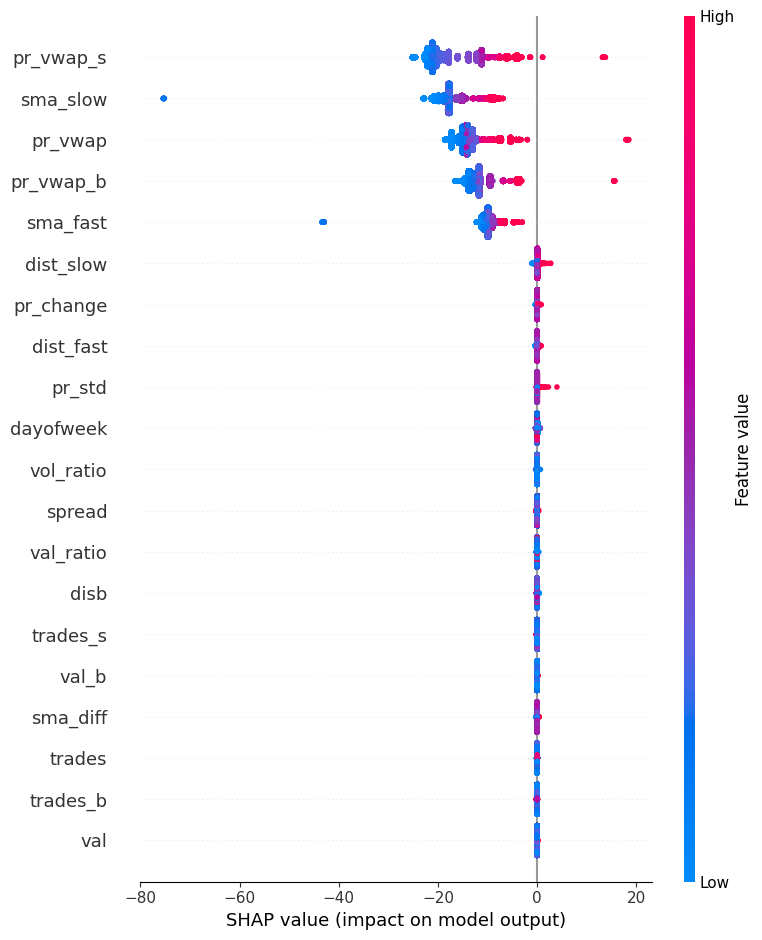

In [40]:
import shap
# shap_values содержат базовое значение в последнем столбце, берем всё кроме него
shap.summary_plot(shap_values[:, :-1], X_test)

# создание датасета для метамодели 

In [41]:
base_models = {
    '5': model_catboost.model_5m,
    '10': model_catboost.model_10m,
    '15': model_catboost.model_15m,
    }

In [39]:
def build_meta_dataset(X_meta_source, y_meta_source, models_dict):
    """
    Создает признаки для метамодели: текущие прогнозы + прошлые ошибки.
    """
    df_meta = pd.DataFrame(index=X_meta_source.index)
    
    # 1. Получаем текущую цену (она нужна для расчета ошибок)
    df_meta['current_price'] = X_meta_source['current_price']
    
    # 2. Генерируем "свежие" прогнозы базовых моделей на будущее (t+5, t+10, t+15)
    df_meta['base_pred_5m'] = models_dict['5'].predict(X_meta_source)
    df_meta['base_pred_10m'] = models_dict['10'].predict(X_meta_source)
    df_meta['base_pred_15m'] = models_dict['15'].predict(X_meta_source)
    
    # 3. РАСЧЕТ ИСТОРИЧЕСКИХ ОШИБОК (Критический шаг без заглядывания)
    # Прогноз на +5м, сделанный 1 шаг назад (5 мин назад), должен был исполниться СЕЙЧАС.
    past_pred_5m = df_meta['base_pred_5m'].shift(1)
    # Прогноз на +10м, сделанный 2 шага назад (10 мин назад), должен был исполниться СЕЙЧАС.
    past_pred_10m = df_meta['base_pred_10m'].shift(2)
    # Прогноз на +15м, сделанный 3 шага назад (15 мин назад), должен был исполниться СЕЙЧАС.
    past_pred_15m = df_meta['base_pred_15m'].shift(3)
    
    # Ошибка = Истинная цена сейчас - То, что модель предсказывала в прошлом
    df_meta['error_5m'] = df_meta['current_price'] - past_pred_5m
    df_meta['error_10m'] = df_meta['current_price'] - past_pred_10m
    df_meta['error_15m'] = df_meta['current_price'] - past_pred_15m
    
    # 4. Добавляем важные контекстные рыночные фичи (силу тренда и объёмы)
    market_context = [
        'spread', 'vol_ratio', 'val_ratio', 'vwap_spread', 
        'sma_diff', 'dist_fast', 'dist_slow', 'hour', 'minute'
    ]
    for col in market_context:
        df_meta[col] = X_meta_source[col]
        
    # 5. Привязываем таргеты (будущие цены)
    for h in ['5', '10', '15']:
        df_meta[f'target_{h}m'] = y_meta_source[f'target_{h}m']
        
    # Дропаем первые 3 строки, так как для них еще не накопились прошлые ошибки (из-за shift)
    df_meta = df_meta.dropna().reset_index(drop=True)
    
    return df_meta

# Формируем датасет для обучения метамодели на основе X_test
meta_train_data = build_meta_dataset(X_test, y_test, base_models)

In [193]:
historical_data = preprocessing_data(data)
prophet_json_path = "prophet_model.json"
cb_paths = {
    '5':'catboost_model_5.cbm', '10':'catboost_model_10.cbm', '15':'catboost_model_15.cbm'
}
feature_cols_cb = feature_cols

In [41]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX

def generate_meta_dataset(historical_data, prophet_json_path, cb_paths, feature_cols_cb):
    df = historical_data.copy(deep=True)
    df = df.sort_values('tradetime').reset_index(drop=True)
    df['tradetime'] = pd.to_datetime(df['tradetime']).dt.tz_localize(None)
    
    # 1. Инициализируем базовые инференс-классы
    arima_forecaster = RealTimeForecaster(p=3, q=2)
    prophet_forecaster = RealTimeProphetForecaster(prophet_json_path)
    catboost_forecaster = RealTimeCatBoostForecaster(cb_paths['5'], cb_paths['10'], cb_paths['15'])
    
    meta_rows = []
    window_size = 30 
    
    print(f"Старт отладочной сборки. Всего строк в истории: {len(df)}")
    
    # Выводим первую ошибку наружу, чтобы понять причину
    error_logged = False 
    
    for i in tqdm(range(window_size, len(df))):
        current_row = df.iloc[i]
        last_time = current_row['tradetime']
        price_now = current_row['current_price']
        
        # Защита стыков сессий MoEX
        current_time_only = last_time.time()
        if current_time_only > pd.to_datetime('23:35:00').time() and current_time_only <= pd.to_datetime('23:50:00').time():
            continue
        if current_time_only > pd.to_datetime('18:35:00').time() and current_time_only < pd.to_datetime('19:00:00').time():
            continue
            
        # Нарезаем окно (сбрасываем индексы в 0..30 для стабильности ARIMA)
        df_window_with_current = df.iloc[i - window_size : i + 1].copy().reset_index(drop=True)
        
        try:
            # --- 1. ОПРОС ARIMA (без extend, через стандартный метод класса) ---
            res_arima = arima_forecaster.predict_on_dataframe(df_window_with_current)
            
            # --- 2. ОПРОС PROPHET ---
            res_prophet = prophet_forecaster.predict_on_dataframe(df_window_with_current)
            
            # --- 3. ОПРОС CATBOOST ---
            res_cb = catboost_forecaster.predict_on_dataframe(df_window_with_current)
            
            # ОТЛАДКА: Если какая-то модель вернула None, логируем это один раз
            if (res_arima is None or res_prophet is None or res_cb is None) and not error_logged:
                print("\n[ОТЛАДКА] Одна из моделей вернула None:")
                print(f"ARIMA: {type(res_arima)}, Prophet: {type(res_prophet)}, CatBoost: {type(res_cb)}")
                error_logged = True
                continue
                
            if res_arima is None or res_prophet is None or res_cb is None:
                continue
                
            arima_p = res_arima['return_pred'].values
            prophet_p = res_prophet['return_pred'].values
            cb_p = res_cb['return_pred'].values
            
            meta_rows.append({
                'tradetime': last_time,
                'current_price': price_now,
                'arima_p5': arima_p[0], 'arima_p10': arima_p[1], 'arima_p15': arima_p[2],
                'prophet_p5': prophet_p[0], 'prophet_p10': prophet_p[1], 'prophet_p15': prophet_p[2],
                'catboost_p5': cb_p[0], 'catboost_p10': cb_p[1], 'catboost_p15': cb_p[2],
                'spread': current_row['spread'], 
                'vol_ratio': current_row['vol_ratio'], 
                'val_ratio': current_row['val_ratio'], 
                'vwap_spread': current_row['vwap_spread'],
                'sma_diff': current_row['sma_diff'],
                'dist_fast': current_row['dist_fast'],
                'dist_slow': current_row['dist_slow'],
                'hour': current_row['hour'],
                'minute': current_row['minute'],
                'target_5m': current_row['target_5m'],
                'target_10m': current_row['target_10m'],
                'target_15m': current_row['target_15m']
            })
        except Exception as e:
            if not error_logged:
                print(f"\n[КРИТИЧЕСКАЯ ОШИБКА В ЦИКЛЕ]: {e}")
                error_logged = True
            continue
        
    df_meta = pd.DataFrame(meta_rows)
    if df_meta.empty:
        print("Ошибка: Не удалось собрать ни одной валидной мета-строки.")
        return None
    
    print("\nРасчет прошлых ошибок моделей...")
    for algo in ['arima', 'prophet', 'catboost']:
        df_meta[f'{algo}_err_5m'] = df_meta['current_price'] - df_meta[f'{algo}_p5'].shift(1)
        df_meta[f'{algo}_err_10m'] = df_meta['current_price'] - df_meta[f'{algo}_p10'].shift(2)
        df_meta[f'{algo}_err_15m'] = df_meta['current_price'] - df_meta[f'{algo}_p15'].shift(3)
        
    df_meta = df_meta.dropna().reset_index(drop=True)
    print(f"Сборка завершена успешно! Итого строк для метамодели: {len(df_meta)}")
    return df_meta



In [45]:
idx_split_meta = int(len(historical_data) * 0.7)
meta_train = historical_data.iloc[:idx_split_meta].copy()
meta_test = historical_data.iloc[idx_split_meta:].copy()

In [46]:
data_meta_train = generate_meta_dataset(meta_train, prophet_json_path, cb_paths, feature_cols_cb)

Старт отладочной сборки. Всего строк в истории: 189315


100%|██████████| 189285/189285 [4:43:42<00:00, 11.12it/s]  



Расчет прошлых ошибок моделей...
Сборка завершена успешно! Итого строк для метамодели: 184995


In [47]:
data_meta_train.to_parquet(f'data_meta_train.parquet')

In [48]:
data_meta_test = generate_meta_dataset(meta_test, prophet_json_path, cb_paths, feature_cols_cb)

Старт отладочной сборки. Всего строк в истории: 81136


100%|██████████| 81106/81106 [2:03:35<00:00, 10.94it/s]  



Расчет прошлых ошибок моделей...
Сборка завершена успешно! Итого строк для метамодели: 79160


In [49]:
data_meta_test.to_parquet(f'data_meta_test.parquet')

In [42]:
df_loaded_meta_train = pd.read_parquet('data_meta_train.parquet')

In [43]:
df_loaded_meta_test = pd.read_parquet(f'data_meta_test.parquet')

In [44]:
import numpy as np
import pandas as pd

def create_unified_target(df, min_profit=0.001):
    df = df.copy()
    
    # 1. Считаем чистые изменения цены для каждого горизонта относительно текущей цены
    change_5m = (df['target_5m'] / df['current_price']) - 1
    change_10m = (df['target_10m'] / df['current_price']) - 1
    change_15m = (df['target_15m'] / df['current_price']) - 1
    
    # 2. Издержки на круг (0.04% комиссия + 0.01% проскальзывание) * 2 = 0.001 (0.1%)
    total_costs = (0.0004 + 0.0001) * 2
    
    # 3. Находим максимальный потенциал движения вверх и вниз на всем отрезке 15 минут
    max_up_potential = np.maximum.reduce([change_5m, change_10m, change_15m]) - total_costs
    max_down_potential = np.maximum.reduce([-change_5m, -change_10m, -change_15m]) - total_costs
    
    # 4. Формируем 3 класса для CatBoostClassifier:
    # 0: SELL (чистая прибыль от падения > порога)
    # 2: BUY  (чистая прибыль от роста > порога)
    # 1: HOLD (движение не окупает издержки)
    conditions = [
        (max_up_potential > min_profit) & (max_up_potential > max_down_potential),   # Класс 2: BUY
        (max_down_potential > min_profit) & (max_down_potential > max_up_potential)  # Класс 0: SELL
    ]
    choices = [2, 0]
    
    df['unified_target'] = np.select(conditions, choices, default=1)
    return df

In [45]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight

# Добавляем единый таргет в ваш мета-датасет
df_meta_classified_train = create_unified_target(df_loaded_meta_train, min_profit=0.001)
df_meta_classified_test = create_unified_target(df_loaded_meta_test, min_profit=0.001)

# Фичи метамодели (включают ВСЕ горизонты всех трех базовых алгоритмов)
meta_features = [
    # Базовые прогнозы
    'arima_p5', 'arima_p10', 'arima_p15',
    'prophet_p5', 'prophet_p10', 'prophet_p15',
    'catboost_p5', 'catboost_p10', 'catboost_p15',
    # Накопленные ошибки базовых моделей
    'arima_err_5m', 'arima_err_10m', 'arima_err_15m',
    'prophet_err_5m', 'prophet_err_10m', 'prophet_err_15m',
    'catboost_err_5m', 'catboost_err_10m', 'catboost_err_15m',
    # Стаканные и технические фичи рынка
    'current_price', 'spread', 'vol_ratio', 'val_ratio', 'vwap_spread', 
    'sma_diff', 'dist_fast', 'dist_slow', 'hour', 'minute'
]

# Хронологический сплит (80/20)

meta_train = df_meta_classified_train
meta_test = df_meta_classified_test

# Балансировка весов (класс HOLD на бирже всегда доминирует)
classes = np.unique(meta_train['unified_target'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=meta_train['unified_target'])
class_weights_dict = dict(zip(classes, weights))

# Инициализация и обучение единого классификатора
meta_classifier = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.001,
    depth=7,
    loss_function='MultiClass',
    eval_metric='TotalF1', # Оцениваем по сбалансированной F1-метрике
    class_weights=class_weights_dict,
    random_seed=42,
    early_stopping_rounds=2500
)

meta_classifier.fit(
    meta_train[meta_features], meta_train['unified_target'],
    eval_set=(meta_test[meta_features], meta_test['unified_target']),
    verbose=100
)

meta_classifier.save_model('unified_meta_classifier.cbm')

0:	learn: 0.4793930	test: 0.3587791	best: 0.3587791 (0)	total: 30.4ms	remaining: 2m 32s
100:	learn: 0.4941247	test: 0.3854166	best: 0.3873079 (56)	total: 1.5s	remaining: 1m 12s
200:	learn: 0.4950387	test: 0.3870723	best: 0.3873858 (188)	total: 2.89s	remaining: 1m 8s
300:	learn: 0.4955803	test: 0.3870690	best: 0.3878422 (236)	total: 4.23s	remaining: 1m 6s
400:	learn: 0.4966863	test: 0.3881888	best: 0.3883279 (387)	total: 5.56s	remaining: 1m 3s
500:	learn: 0.4973233	test: 0.3888578	best: 0.3891002 (468)	total: 6.89s	remaining: 1m 1s
600:	learn: 0.4979737	test: 0.3898963	best: 0.3898963 (600)	total: 8.25s	remaining: 1m
700:	learn: 0.4980821	test: 0.3902730	best: 0.3907251 (673)	total: 9.66s	remaining: 59.3s
800:	learn: 0.4985454	test: 0.3933906	best: 0.3933906 (800)	total: 11.1s	remaining: 58.2s
900:	learn: 0.4994635	test: 0.3977490	best: 0.3977502 (899)	total: 12.4s	remaining: 56.5s
1000:	learn: 0.4999402	test: 0.4006912	best: 0.4006912 (1000)	total: 13.9s	remaining: 55.5s
1100:	learn: 0

In [46]:
def predict_meta_signal(self, df_window):
        """
        Принимает скользящее окно из ClickHouse.
        Возвращает итоговое торговое действие прямо сейчас.
        """
        # Сборка вектора X_meta (логика из предыдущих шагов полностью сохраняется)
        X_meta = self._prepare_meta_features_vector(df_window) 
        
        # Получаем предсказанный класс (0, 1, 2)
        predicted_class = self.meta_model_unified.predict(X_meta)[0]
        
        # Получаем вероятности распределения классов
        probabilities = self.meta_model_unified.predict_proba(X_meta)[0]
        
        signal_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
        
        return {
            'tradetime': df_window['tradetime'].iloc[-1],
            'current_price': df_window['pr_close'].iloc[-1],
            'signal': signal_map[predicted_class],
            'confidence': np.max(probabilities), # Уверенность модели в выбранном сигнале
            'prob_sell': probabilities[0],
            'prob_hold': probabilities[1],
            'prob_buy': probabilities[2]
        }

In [47]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor

class RealTimeMetaEnsemble:
    def __init__(self, prophet_path, cb_paths, meta_classifier_path):
        """
        Управляющий класс мета-ансамбля (Стекинг 2-го уровня).
        
        prophet_path: путь к json-файлу базовой модели Prophet
        cb_paths: словарь путей к базовым CatBoost {'5': path, '10': path, '15': path}
        meta_classifier_path: путь к обученной единой метамодели-классификатору
        """
        # 1. Инициализируем базовые инференс-классы (1 уровень)
        self.arima_forecaster = RealTimeForecaster(p=3, q=2)
        self.prophet_forecaster = RealTimeProphetForecaster(prophet_path)
        self.catboost_forecaster = RealTimeCatBoostForecaster(cb_paths['5'], cb_paths['10'], cb_paths['15'])
        
        # 2. Загружаем единую метамодель классификации (2 уровень)
        self.meta_classifier = CatBoostClassifier().load_model(meta_classifier_path)
        
        # Строгий порядок колонок-признаков для мета-классификатора (должен совпадать с обучением)
        self.meta_feature_cols = [
            'arima_p5', 'arima_p10', 'arima_p15',
            'prophet_p5', 'prophet_p10', 'prophet_p15',
            'catboost_p5', 'catboost_p10', 'catboost_p15',
            'arima_err_5m', 'arima_err_10m', 'arima_err_15m',
            'prophet_err_5m', 'prophet_err_10m', 'prophet_err_15m',
            'catboost_err_5m', 'catboost_err_10m', 'catboost_err_15m',
            'current_price', 'spread', 'vol_ratio', 'val_ratio', 'vwap_spread', 
            'sma_diff', 'dist_fast', 'dist_slow', 'hour', 'minute'
        ]
        
        # Карта перевода числовых выходов классификатора в торговые приказы
        self.signal_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
        
        # Внутренний оперативный буфер памяти для расчета скользящих ошибок прошлого
        # Структура: {timestamp: {'arima': [p5, p10, p15], 'prophet': [...], 'catboost': [...]}}
        self.predictions_history = {}

    def _calculate_rolling_errors(self, last_time, price_now):
        """
        Внутренний метод: находит в памяти прогнозы, сделанные 5, 10 и 15 минут назад
        под ТЕКУЩИЙ момент времени, и вычисляет чистую ошибку алгоритмов.
        """
        # Вычисляем временные метки "прошлого"
        t_5 = last_time - pd.Timedelta(minutes=5)
        t_10 = last_time - pd.Timedelta(minutes=10)
        t_15 = last_time - pd.Timedelta(minutes=15)
        
        errs = {}
        for algo in ['arima', 'prophet', 'catboost']:
            # Извлекаем то точечное предсказание, которое делалось назад во времени под текущую минуту
            # Индексы массивов: [0] = прогноз на +5м, [1] = прогноз на +10м, [2] = прогноз на +15м
            pred_5m_ago = self.predictions_history.get(t_5, {}).get(algo, [price_now, price_now, price_now])[0]
            pred_10m_ago = self.predictions_history.get(t_10, {}).get(algo, [price_now, price_now, price_now])[1]
            pred_15m_ago = self.predictions_history.get(t_15, {}).get(algo, [price_now, price_now, price_now])[2]
            
            # Ошибка = Реальность сейчас - То, что прогнозировали в прошлом под этот момент
            errs[f'{algo}_err_5m'] = price_now - pred_5m_ago
            errs[f'{algo}_err_10m'] = price_now - pred_10m_ago
            errs[f'{algo}_err_15m'] = price_now - pred_15m_ago
            
        # Защита от утечки ОЗУ: очищаем буфер от записей старше 15 минут
        self.predictions_history = {k: v for k, v in self.predictions_history.items() if k >= t_15}
        
        return errs

    def predict_trade_signal(self, df_window):
        """
        Главный метод инференса реального времени. 
        Принимает скользящее окно из ClickHouse.
        Возвращает словарь с финальным торговым решением и скором уверенности.
        """
        if len(df_window) < 12:
            print("Ошибка ансамбля: Окно данных из ClickHouse должно быть не менее 12 строк.")
            return None
            
        # Стандартизация фрейма
        df_window = df_window.copy()
        df_window['tradetime'] = pd.to_datetime(df_window['tradetime']).dt.tz_localize(None)
        df_window = df_window.sort_values('tradetime').reset_index(drop=True)
        
        last_time = df_window['tradetime'].iloc[-1]
        price_now = df_window['pr_close'].iloc[-1]
        
        try:
            # 1. ОПРОС БАЗОВЫХ МОДЕЛЕЙ (1 уровень)
            res_arima = self.arima_forecaster.predict_on_dataframe(df_window)
            res_prophet = self.prophet_forecaster.predict_on_dataframe(df_window)
            res_cb = self.catboost_forecaster.predict_on_dataframe(df_window)
            
            # Извлекаем массивы предсказаний [pred_5m, pred_10m, pred_15m]
            arima_pred = res_arima['return_pred'].values if res_arima is not None else [price_now] * 3
            prophet_pred = res_prophet['return_pred'].values if res_prophet is not None else [price_now] * 3
            cb_pred = res_cb['return_pred'].values if res_cb is not None else [price_now] * 3
            
            # 2. РАСЧЕТ ИСТОРИЧЕСКИХ ОШЕБОК (Через локальный буфер)
            errs_dict = self._calculate_rolling_errors(last_time, price_now)
            
            # 3. СОХРАНЕНИЕ ТЕКУЩИХ ПРОГНОЗОВ (Для следующих шагов инференса)
            self.predictions_history[last_time] = {
                'arima': arima_pred, 'prophet': prophet_pred, 'catboost': cb_pred
            }
            
            # 4. ИЗВЛЕЧЕНИЕ РЫНОЧНОГО КОНТЕКСТА
            # Забираем рассчитанные технические/стаканные фичи из экстрактора базового CatBoost
            X_cb_context = self.catboost_forecaster._extract_features(df_window)
            
            # 5. СБОРКА ЕДИНОГО ВЕКТОРА ПРИЗНАКОВ ДЛЯ МЕТА-КЛАССИФИКАТОРА
            meta_input = pd.DataFrame([{
                # Базовые прогнозы
                'arima_p5': arima_pred[0], 'arima_p10': arima_pred[1], 'arima_p15': arima_pred[2],
                'prophet_p5': prophet_pred[0], 'prophet_p10': prophet_pred[1], 'prophet_p15': prophet_pred[2],
                'catboost_p5': cb_pred[0], 'catboost_p10': cb_pred[1], 'catboost_p15': cb_pred[2],
                # Распаковываем посчитанные ошибки прошлого
                **errs_dict,
                # Рыночные контекстные признаки
                'current_price': price_now,
                'spread': X_cb_context['spread'].iloc[0],
                'vol_ratio': X_cb_context['vol_ratio'].iloc[0],
                'val_ratio': X_cb_context['val_ratio'].iloc[0],
                'vwap_spread': X_cb_context['vwap_spread'].iloc[0],
                'sma_diff': X_cb_context['sma_diff'].iloc[0],
                'dist_fast': X_cb_context['dist_fast'].iloc[0],
                'dist_slow': X_cb_context['dist_slow'].iloc[0],
                'hour': int(X_cb_context['hour'].iloc[0]),
                'minute': int(X_cb_context['minute'].iloc[0])
            }])
            
            # Выстраиваем признаки в строгом соответствии с матрицей обучения
            X_meta = meta_input[self.meta_feature_cols]
            
            # 6. ИНФЕРЕНС МЕТА-КЛАССИФИКАТОРА (2 уровень)
            predicted_class = self.meta_classifier.predict(X_meta)[0][0]
            probabilities = self.meta_classifier.predict_proba(X_meta)[0] # Массив [prob_sell, prob_hold, prob_buy]
            
            return {
                'tradetime': last_time,
                'current_price': price_now,
                'signal': self.signal_map[predicted_class],
                'confidence': np.max(probabilities), # Уверенность в выбранном классе
                'prob_sell': np.round(probabilities[0], 4),
                'prob_hold': np.round(probabilities[1], 4),
                'prob_buy': np.round(probabilities[2], 4)
            }
            
        except Exception as e:
            print(f"Критический сбой внутри RealTimeMetaEnsemble: {e}")
            return None


In [49]:
prophet_json_path = "prophet_model.json"
cb_paths = {
    '5':'catboost_model_5.cbm', '10':'catboost_model_10.cbm', '15':'catboost_model_15.cbm'
}
feature_cols_cb = feature_cols

meta_classifier_path = 'unified_meta_classifier.cbm'

In [50]:
meta_model = RealTimeMetaEnsemble(prophet_json_path, cb_paths, meta_classifier_path)

In [82]:
meta_model.predict_trade_signal(client.get_latest_window(secid='GAZP', window_size=200))

Error on localhost:9000 ping: Unexpected EOF while reading bytes
Connection was closed, reconnecting.


{'tradetime': Timestamp('2026-06-11 12:30:00'),
 'current_price': np.float64(113.38),
 'signal': 'SELL',
 'confidence': np.float64(0.46206397064899796),
 'prob_sell': np.float64(0.4621),
 'prob_hold': np.float64(0.1412),
 'prob_buy': np.float64(0.3967)}

In [52]:
raw_test

,tradetime,pr_open,pr_high,pr_low,pr_close,pr_std,vol,val,trades,pr_vwap,pr_change,trades_b,trades_s,val_b,val_s,vol_b,vol_s,disb,pr_vwap_b,pr_vwap_s
190015,2025-01-13 13:00:00+03:00,130.14,130.35,130.12,130.12,0.0001,36532,47585284.0,638,130.26,-0.0154,368,270,31389320.0,16195964.0,24100,12432,0.32,130.25,130.28
190016,2025-01-13 13:05:00+03:00,130.12,130.12,129.65,129.70,0.0001,73933,95996155.0,986,129.84,-0.3228,322,664,19396224.0,76599931.0,14941,58992,-0.60,129.82,129.85
190017,2025-01-13 13:10:00+03:00,129.70,130.02,129.54,129.85,0.0001,48532,62980206.0,866,129.77,0.1157,451,415,28165490.0,34814716.0,21699,26833,-0.11,129.80,129.75
190018,2025-01-13 13:15:00+03:00,129.86,129.91,129.41,129.54,0.0001,61736,80015095.0,942,129.61,-0.2464,281,661,22807206.0,57207889.0,17600,44136,-0.43,129.59,129.62
190019,2025-01-13 13:20:00+03:00,129.54,129.87,129.53,129.76,0.0001,38113,49429471.0,720,129.69,0.1698,434,286,33639458.0,15790012.0,25935,12178,0.36,129.71,129.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271445,2026-06-11 12:10:00+03:00,113.14,113.28,113.09,113.14,0.0001,25565,28929551.0,318,113.16,0.0000,199,119,20483379.0,8446172.0,18101,7464,0.42,113.16,113.16
271446,2026-06-11 12:15:00+03:00,113.15,113.17,113.06,113.12,0.0001,7320,8279886.0,199,113.11,-0.0265,98,101,3803433.0,4476453.0,3362,3958,-0.08,113.13,113.10
271447,2026-06-11 12:20:00+03:00,113.13,113.21,113.12,113.14,0.0001,3412,3860705.0,166,113.15,0.0088,94,72,1991730.0,1868975.0,1760,1652,0.03,113.17,113.13
271448,2026-06-11 12:25:00+03:00,113.15,113.19,113.12,113.13,0.0001,6572,7436113.0,155,113.15,-0.0177,91,64,5015215.0,2420898.0,4432,2140,0.35,113.16,113.13


In [ ]:
len(raw_test[:100])

100

In [53]:
data_predict = {}

In [54]:
from tqdm import tqdm

In [55]:
data_predict = pd.DataFrame()

In [56]:
data_predict.empty

True

In [ ]:
for i in tqdm(range(len(raw_test))):

    if len(raw_test[i:i+200])<200:
        break
    else:
        if data_predict.empty:
            data_predict = pd.DataFrame(meta_model.predict_trade_signal(raw_test[i:i+200]), index=[0])
        else:
            data_predict = pd.concat([data_predict, pd.DataFrame([meta_model.predict_trade_signal(raw_test[i:i+200])])], ignore_index=True)


In [59]:
data_predict

,tradetime,current_price,signal,confidence,prob_sell,prob_hold,prob_buy
0,2025-01-14 16:10:00,134.08,SELL,0.376778,0.3768,0.2571,0.3661
1,2025-01-14 16:15:00,134.09,HOLD,0.361329,0.3150,0.3613,0.3236
2,2025-01-14 16:20:00,134.11,BUY,0.374925,0.3615,0.2636,0.3749
3,2025-01-14 16:25:00,133.96,BUY,0.427328,0.4058,0.1669,0.4273
4,2025-01-14 16:30:00,133.89,BUY,0.393986,0.3864,0.2196,0.3940
...,...,...,...,...,...,...,...
81231,2026-06-11 12:10:00,113.14,SELL,0.419033,0.4190,0.1841,0.3968
81232,2026-06-11 12:15:00,113.12,BUY,0.389882,0.3842,0.2259,0.3899
81233,2026-06-11 12:20:00,113.14,BUY,0.388645,0.3691,0.2423,0.3886
81234,2026-06-11 12:25:00,113.13,BUY,0.387984,0.3445,0.2676,0.3880


In [60]:
data_predict.to_parquet(f'data_predict.parquet')

In [7]:
data_predict = pd.read_parquet(f'data_predict.parquet')

In [8]:
data_predict

,tradetime,current_price,signal,confidence,prob_sell,prob_hold,prob_buy
0,2025-01-14 16:10:00,134.08,SELL,0.376778,0.3768,0.2571,0.3661
1,2025-01-14 16:15:00,134.09,HOLD,0.361329,0.3150,0.3613,0.3236
2,2025-01-14 16:20:00,134.11,BUY,0.374925,0.3615,0.2636,0.3749
3,2025-01-14 16:25:00,133.96,BUY,0.427328,0.4058,0.1669,0.4273
4,2025-01-14 16:30:00,133.89,BUY,0.393986,0.3864,0.2196,0.3940
...,...,...,...,...,...,...,...
81231,2026-06-11 12:10:00,113.14,SELL,0.419033,0.4190,0.1841,0.3968
81232,2026-06-11 12:15:00,113.12,BUY,0.389882,0.3842,0.2259,0.3899
81233,2026-06-11 12:20:00,113.14,BUY,0.388645,0.3691,0.2423,0.3886
81234,2026-06-11 12:25:00,113.13,BUY,0.387984,0.3445,0.2676,0.3880


In [9]:
data_predict["signal"].unique()

array(['SELL', 'HOLD', 'BUY'], dtype=object)

In [32]:
#========================================
initial_cash = 100000.0
cash = initial_cash
shares = 0
allocation_pct = 0.10  # Тратить 10% от капитала на одну сделку

portfolio_values = []

for idx, row in data_predict.iterrows():
    price = row['current_price']
    signal = row['signal']
    
    # Текущая полная стоимость портфеля на этот шаг
    current_portfolio_value = cash + (shares * price)
    
    if signal == "BUY":
        # Считаем, сколько денег выдать на сделку
        money_to_spend = current_portfolio_value * allocation_pct
        
        # Считаем количество целых акций (округляем вниз)
        trade_size = int(money_to_spend // price)
        
        if trade_size > 0 and cash >= trade_size * price:
            cash -= trade_size * price
            shares += trade_size
            
    elif signal == "SELL":
        # Если сигнал SELL — полностью закрываем позицию (или фиксированный процент)
        # Для примера: продаем всё, что накопили
        if shares > 0:
            cash += shares * price
            shares = 0
            
    total_value = cash + (shares * price)
    portfolio_values.append(total_value)


In [34]:
final_return = (portfolio_values[-1]-initial_cash)/initial_cash*100
from_data = str(data_predict["tradetime"].min())
to_data = str(data_predict["tradetime"].max())
trade_buy = sum(data_predict["signal"]=="BUY")
buy_and_hold = (data_predict["current_price"].diff()*10).cumsum().iloc[-1]
print("Стратегия оценивалась на акции GAZP, 10% от капитала на одну сделку")
print(f"Тестирование стратегии с {from_data} по {to_data}")
print(f"Начальная стоимость портфеля: {initial_cash:.2f}")
print(f"Максимальная просадка портфеля: {min(portfolio_values):.2f}")
print(f"Кол-во сделок (покупок): {trade_buy:.2f}")
print(f"Итоговая стоимость портфеля: {portfolio_values[-1]:.2f}")
print(f"Доходность стратегии: {final_return:.2f}%")
print(f"Доходность стратегии Buy and Hold: {buy_and_hold:.2f}%")

Стратегия оценивалась на акции GAZP, 10% от капитала на одну сделку
Тестирование стратегии с 2025-01-14 16:10:00 по 2026-06-11 12:30:00
Начальная стоимость портфеля: 100000.00
Максимальная просадка портфеля: 99978.40
Кол-во сделок (покупок): 14545.00
Итоговая стоимость портфеля: 165278.66
Доходность стратегии: 65.28%
Доходность стратегии Buy and Hold: -207.00%


In [35]:
initial_cash = 100000.0
cash = initial_cash
shares = 0
trade_size = 10

In [36]:
portfolio_values = []

In [37]:
for idx, row in data_predict.iterrows():
    price = row['current_price']
    signal = row['signal']
    if signal=="BUY":
        if cash>trade_size*price:
            cash -= trade_size * price
            shares += trade_size
    elif signal=="SELL":
        if shares >= trade_size:
            cash += trade_size * price
            shares -= trade_size
    total_value = cash + (shares * price)
    portfolio_values.append(total_value)


In [38]:
final_return = (portfolio_values[-1]-initial_cash)/initial_cash*100

In [40]:
from_data = str(data_predict["tradetime"].min())
to_data = str(data_predict["tradetime"].max())
trade_buy = sum(data_predict["signal"]=="BUY")
buy_and_hold = (data_predict["current_price"].diff()*10).cumsum().iloc[-1]

In [41]:
print("Стратегия оценивалась на акции GAZP, покупка 1 лота")
print(f"Тестирование стратегии с {from_data} по {to_data}")
print(f"Начальная стоимость портфеля: {initial_cash:.2f}")
print(f"Максимальная просадка портфеля: {min(portfolio_values):.2f}")
print(f"Кол-во сделок (покупок): {trade_buy:.2f}")
print(f"Итоговая стоимость портфеля: {portfolio_values[-1]:.2f}")
print(f"Доходность стратегии: {final_return:.2f}%")
print(f"Доходность стратегии Buy and Hold: {buy_and_hold:.2f}%")

Стратегия оценивалась на акции GAZP, покупка 1 лота
Тестирование стратегии с 2025-01-14 16:10:00 по 2026-06-11 12:30:00
Начальная стоимость портфеля: 100000.00
Максимальная просадка портфеля: 98096.20
Кол-во сделок (покупок): 14545.00
Итоговая стоимость портфеля: 107677.30
Доходность стратегии: 7.68%
Доходность стратегии Buy and Hold: -207.00%


# В стратегии использовались три модели:
* SARIMA
* Prophet
* CatBoostRegressor

Прогнозирование цены закрытия в интервале 5 минут, t+1(5), t+2(10),t+3(15).

Результата прогнозирования и ошибка предсказания использовались для обучения метамодели.

# метамодель 
* CatBoostClassifier
signal_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}

Покупка BUY 10 акции GAZP (1 лот),  SELL продажа, HOLD сделки не осушесвлялись. расчет производился без учета комисии и проскальзывания. 

* Тестирование стратегии с 2025-01-10 21:15:00 по 2026-06-09 14:30:00
* Начальная стоимость портфеля: 100000.00
* Максимальная просадка портфеля: 99279.50
* Кол-во сделок (покупок): 14679.00
* Итоговая стоимость портфеля: 108785.00
* Доходность стратегии: 8.78%
* Доходность стратегии Buy and Hold: -132.40%

# возможные улучшения
* добавление к ансамблю RNN, Transformer либо VSN
* добавление доверительного интервала в прогноз моделей
* добавление таргет + buy if hold(докупить), sell if hold(частично фиксировать прибыль).
* добавлдение тех индикоторон RSI и т. д.